# Visualización de Resultados — Quiz Módulo 3 (EDA) - (CASO PRACTICO)
## Estadística Aplicada al Negocio — Caso LMB

**Estudiante:** Efraín Sebastián Rojas Artavia

Este notebook grafica en Python los resultados obtenidos en el Quiz del Módulo 3
(Análisis Exploratorio de Datos), usando los mismos datos y respuestas ya
desarrollados a mano en el documento entregado. El objetivo es visualizar cada
ejercicio numérico para reforzar la interpretación de los resultados.

Se sigue la misma paleta de colores y estilo de gráficas usado en los notebooks
anteriores del caso LMB (`#2E86C1` azul, `#E74C3C` rojo para atípicos/alertas,
`#27AE60` verde para líneas centrales, `#AED6F1` azul claro para cajas).

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paleta de colores usada en los notebooks del caso LMB
AZUL = "#2E86C1"
AZUL_CLARO = "#AED6F1"
AZUL_OSCURO = "#1B4F72"
ROJO = "#E74C3C"
ROJO_OSCURO = "#C0392B"
VERDE = "#27AE60"

## Tema 1 — Análisis descriptivo avanzado

### Ejercicio 1.1 — Cuartiles, RIC y valor atípico

Monto (en miles de colones) de 15 pedidos de LMB. Se calculan Q1, Q3, el RIC y
los límites de Tukey (1.5×RIC) para identificar valores atípicos.

In [11]:
# Paso 1: Datos del ejercicio 1.1
pedidos = list(range(1, 16))
montos = [18, 22, 25, 27, 29, 30, 31, 33, 35, 36, 38, 40, 42, 45, 98]

df_pedidos = pd.DataFrame({"Pedido": pedidos, "Monto": montos})

# Paso 2: Cuartiles y RIC (coincide con lo calculado a mano en el quiz)
Q1 = 27
Q3 = 40
RIC = Q3 - Q1
limite_inferior = Q1 - 1.5 * RIC
limite_superior = Q3 + 1.5 * RIC

outliers_111 = df_pedidos[(df_pedidos["Monto"] < limite_inferior) | (df_pedidos["Monto"] > limite_superior)]

print(f"Q1 = {Q1} | Q3 = {Q3} | RIC = {RIC}")
print(f"Límite inferior = {limite_inferior} | Límite superior = {limite_superior}")
print("Outliers detectados:")
print(outliers_111)

Q1 = 27 | Q3 = 40 | RIC = 13
Límite inferior = 7.5 | Límite superior = 59.5
Outliers detectados:
    Pedido  Monto
14      15     98


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21652\801387578.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(


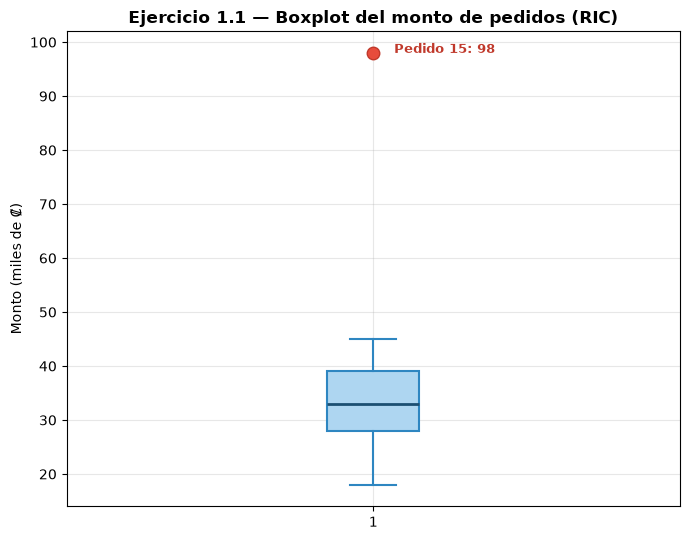

In [12]:
# Boxplot del monto de los 15 pedidos, con el valor atípico resaltado
fig, ax = plt.subplots(figsize=(7, 5.5))

bp = ax.boxplot(
    df_pedidos["Monto"], vert=True, patch_artist=True,
    boxprops=dict(facecolor=AZUL_CLARO, color=AZUL, linewidth=1.5),
    medianprops=dict(color=AZUL_OSCURO, linewidth=2),
    whiskerprops=dict(color=AZUL, linewidth=1.5),
    capprops=dict(color=AZUL, linewidth=1.5),
    flierprops=dict(marker="o", markerfacecolor=ROJO, markeredgecolor=ROJO_OSCURO, markersize=9)
)

for _, row in outliers_111.iterrows():
    ax.annotate(f"Pedido {row['Pedido']}: {row['Monto']}",
                (1, row["Monto"]), textcoords="offset points",
                xytext=(15, 0), fontsize=9, color=ROJO_OSCURO, fontweight="bold")

ax.set_title("Ejercicio 1.1 — Boxplot del monto de pedidos (RIC)", fontsize=12, fontweight="bold")
ax.set_ylabel("Monto (miles de ₡)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Qué se visualiza:** boxplot vertical de los montos de los 15 pedidos. La caja representa Q1–Q3 (₡27 mil–₡40 mil), la línea interna es la mediana, y el punto rojo es el Pedido 15 (₡98 mil), marcado como atípico.

**Razonamiento:** con Q1 = 27, Q3 = 40 y RIC = 13, el límite superior de Tukey (Q3 + 1.5·RIC) es 59.5. El monto de 98 supera ampliamente ese límite, mientras que el resto de los pedidos (18 a 45) se mantiene en un rango compacto.

**Conclusión:** hay un pedido claramente fuera de patrón que conviene revisar antes de usar el monto promedio en proyecciones — podría ser un pedido especial, un cliente corporativo o un error de captura.


### Ejercicio 1.2 — Lectura de un boxplot (tiempo de entrega)

Boxplot construido a partir del resumen de cinco números (Mín, Q1, Mediana, Q3,
Máx) del tiempo de entrega de 50 pedidos, más el valor atípico de 14 días.

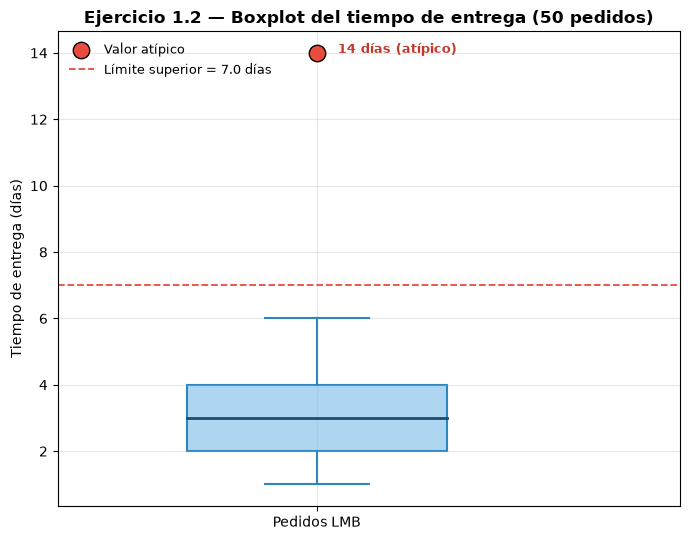

RIC = 2 días | % de pedidos en ≤4 días = 75% (por definición de Q3)


In [13]:
# Datos del ejercicio 1.2: resumen de 5 números + valor atípico
resumen_112 = {"Mínimo": 1, "Q1": 2, "Mediana": 3, "Q3": 4, "Máximo": 6}
valor_atipico_112 = 14
RIC_112 = resumen_112["Q3"] - resumen_112["Q1"]
limite_superior_112 = resumen_112["Q3"] + 1.5 * RIC_112

fig, ax = plt.subplots(figsize=(7, 5.5))

# Bigotes y caja construidos manualmente a partir del resumen de 5 números
ax.plot([1, 1], [resumen_112["Mínimo"], resumen_112["Q1"]], color=AZUL, linewidth=1.5)
ax.plot([1, 1], [resumen_112["Q3"], resumen_112["Máximo"]], color=AZUL, linewidth=1.5)
ax.add_patch(plt.Rectangle((0.75, resumen_112["Q1"]), 0.5,
                            resumen_112["Q3"] - resumen_112["Q1"],
                            facecolor=AZUL_CLARO, edgecolor=AZUL, linewidth=1.5))
ax.plot([0.75, 1.25], [resumen_112["Mediana"]] * 2, color=AZUL_OSCURO, linewidth=2)
ax.plot([0.9, 1.1], [resumen_112["Mínimo"]] * 2, color=AZUL, linewidth=1.5)
ax.plot([0.9, 1.1], [resumen_112["Máximo"]] * 2, color=AZUL, linewidth=1.5)

ax.scatter([1], [valor_atipico_112], color=ROJO, s=140, zorder=4,
           edgecolor="black", label="Valor atípico")
ax.annotate(f"{valor_atipico_112} días (atípico)", (1, valor_atipico_112),
            textcoords="offset points", xytext=(15, 0), fontsize=9,
            color=ROJO_OSCURO, fontweight="bold")
ax.axhline(limite_superior_112, color=ROJO, linestyle="--", linewidth=1.3,
           label=f"Límite superior = {limite_superior_112:.1f} días")

ax.set_title("Ejercicio 1.2 — Boxplot del tiempo de entrega (50 pedidos)", fontsize=12, fontweight="bold")
ax.set_ylabel("Tiempo de entrega (días)")
ax.set_xticks([1])
ax.set_xticklabels(["Pedidos LMB"])
ax.set_xlim(0.5, 1.7)
ax.grid(alpha=0.3)
ax.legend(loc="upper left", fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

print(f"RIC = {RIC_112} días | % de pedidos en ≤{resumen_112['Q3']} días = 75% (por definición de Q3)")

**Qué se visualiza:** boxplot reconstruido a mano (no hay datos crudos, solo el resumen de 5 números), con el valor atípico de 14 días graficado aparte porque excede el bigote superior.

**Razonamiento:** el máximo "normal" de la distribución es 6 días, pero el límite superior de Tukey (Q3 + 1.5·RIC = 7) confirma que 14 días no es simplemente el extremo alto del rango, sino un valor atípico real.

**Dato lógico integrador (no hay datos crudos):** como el ejercicio solo entrega el resumen de 5 números y no las 50 observaciones originales, el boxplot se construye manualmente a partir de ese resumen. Esto alcanza para detectar el atípico, pero no permite ver la forma completa de la distribución (por ejemplo, si existe más de un valor extremo); si se necesitara un diagnóstico más fino habría que solicitar los datos crudos.


### Ejercicio 1.3 — Asimetría y coeficiente de variación

Comparación de la variabilidad relativa (CV) entre el Producto A y el Producto B.

     Producto  Media  Desviación  CV (%)
0  Producto A  45000        6750    15.0
1  Producto B  18000        5400    30.0


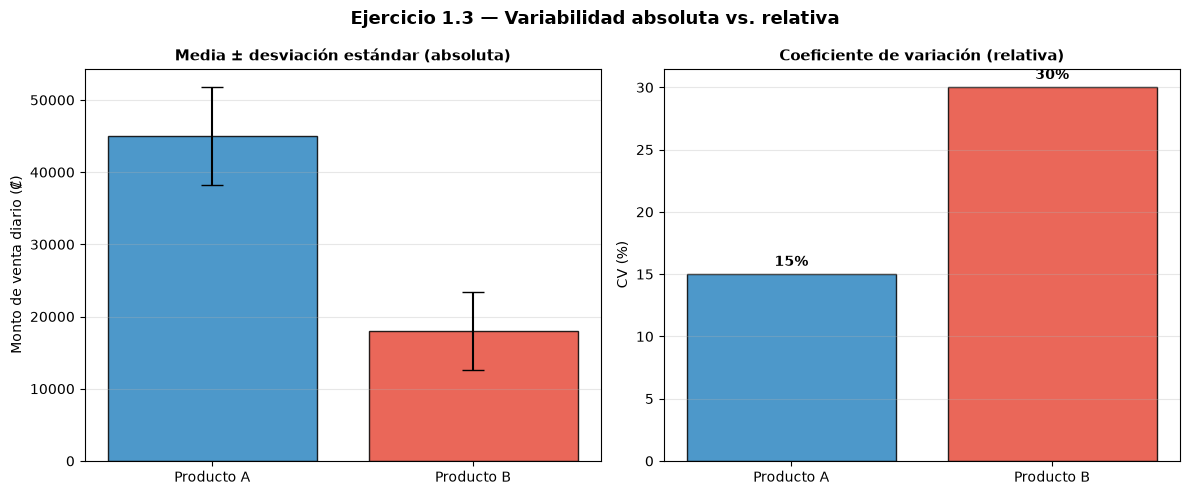

In [14]:
# Datos del ejercicio 1.3
productos_113 = ["Producto A", "Producto B"]
medias_113 = [45000, 18000]
desv_113 = [6750, 5400]
cv_113 = [d / m * 100 for m, d in zip(medias_113, desv_113)]

df_113 = pd.DataFrame({"Producto": productos_113, "Media": medias_113,
                        "Desviación": desv_113, "CV (%)": cv_113})
print(df_113)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colores_113 = [AZUL, ROJO]

# Media ± desviación estándar (variabilidad absoluta)
axes[0].bar(productos_113, medias_113, yerr=desv_113, color=colores_113,
            capsize=8, edgecolor="black", alpha=0.85)
axes[0].set_title("Media ± desviación estándar (absoluta)", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Monto de venta diario (₡)")
axes[0].grid(alpha=0.3, axis="y")

# Coeficiente de variación (variabilidad relativa)
bars = axes[1].bar(productos_113, cv_113, color=colores_113, edgecolor="black", alpha=0.85)
for bar, cv in zip(bars, cv_113):
    axes[1].annotate(f"{cv:.0f}%", (bar.get_x() + bar.get_width() / 2, cv),
                      textcoords="offset points", xytext=(0, 6),
                      ha="center", fontsize=10, fontweight="bold")
axes[1].set_title("Coeficiente de variación (relativa)", fontsize=11, fontweight="bold")
axes[1].set_ylabel("CV (%)")
axes[1].grid(alpha=0.3, axis="y")

plt.suptitle("Ejercicio 1.3 — Variabilidad absoluta vs. relativa", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Qué se visualiza:** dos gráficos de barras lado a lado — variabilidad absoluta (media ± desviación estándar) y variabilidad relativa (coeficiente de variación) — para el Producto A y el Producto B.

**Razonamiento:** el Producto A tiene una desviación estándar absoluta mayor (₡6,750 vs. ₡5,400), pero su CV (15%) es menor que el de B (30%) porque su media también es mucho más alta. En términos relativos, B es el más inestable.

**Conclusión:** al comparar productos con escalas de venta muy distintas, el CV es la métrica correcta de variabilidad, no la desviación estándar absoluta; el Producto B requiere más atención en el control de su variabilidad relativa.


## Tema 2 — Introducción a pruebas estadísticas básicas

### Ejercicio 2.2 — Valor p vs. nivel de significancia (α)

Comparación visual de los tres casos del ejercicio: se rechaza H0 cuando el
valor p cae por debajo de α.

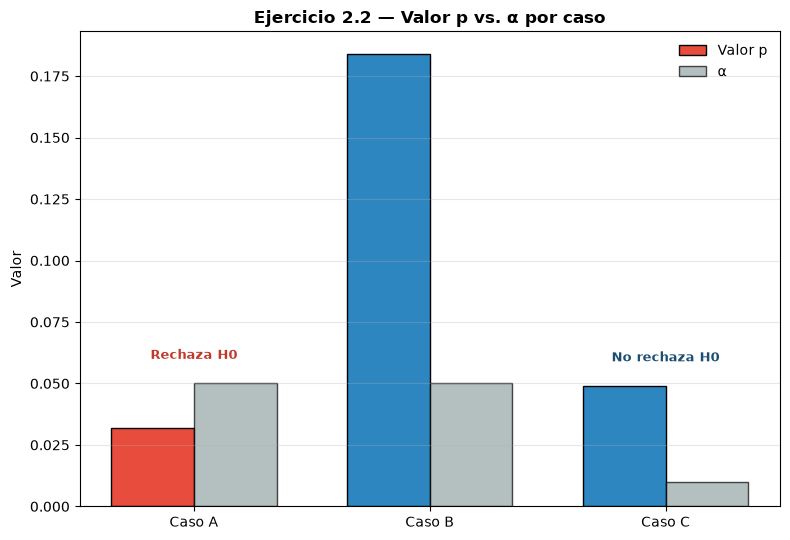

In [15]:
# Datos del ejercicio 2.2
casos_22 = ["Caso A", "Caso B", "Caso C"]
valores_p_22 = [0.032, 0.184, 0.049]
alfas_22 = [0.05, 0.05, 0.01]
decision_22 = ["Rechaza H0" if p < a else "No rechaza H0" for p, a in zip(valores_p_22, alfas_22)]
colores_22 = [ROJO if p < a else AZUL for p, a in zip(valores_p_22, alfas_22)]

fig, ax = plt.subplots(figsize=(8, 5.5))
x = np.arange(len(casos_22))
ancho = 0.35

ax.bar(x - ancho / 2, valores_p_22, ancho, label="Valor p", color=colores_22, edgecolor="black")
ax.bar(x + ancho / 2, alfas_22, ancho, label="α", color="#95A5A6", edgecolor="black", alpha=0.7)

for i, (p, a, d) in enumerate(zip(valores_p_22, alfas_22, decision_22)):
    ax.annotate(d, (x[i], max(p, a) + 0.01), ha="center", fontsize=9,
                fontweight="bold", color=ROJO_OSCURO if "Rechaza" in d else AZUL_OSCURO)

ax.set_xticks(x)
ax.set_xticklabels(casos_22)
ax.set_ylabel("Valor")
ax.set_title("Ejercicio 2.2 — Valor p vs. α por caso", fontsize=12, fontweight="bold")
ax.grid(alpha=0.3, axis="y")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Qué se visualiza:** barras agrupadas por caso comparando el valor p contra α, con la decisión (Rechaza / No rechaza H0) anotada sobre cada par.

**Razonamiento:** solo el Caso A (p = 0.032 < α = 0.05) rechaza H0. El Caso C tiene un valor p bajo (0.049), pero su α es más estricto (0.01), así que no alcanza significancia — la decisión depende tanto del valor p como del criterio elegido, no solo de qué tan "pequeño" luzca el valor p.

**Conclusión:** un valor p pequeño no garantiza significancia si el nivel de exigencia (α) es mayor; α debe fijarse antes de ver los resultados, nunca ajustarse después.


## Tema 3 — Comparación de grupos

### Ejercicio 3.2 — Prueba t para muestras independientes (canales de venta)

Monto promedio de compra: tienda física vs. tienda en línea (valor p = 0.021,
α = 0.05 → se rechaza H0).

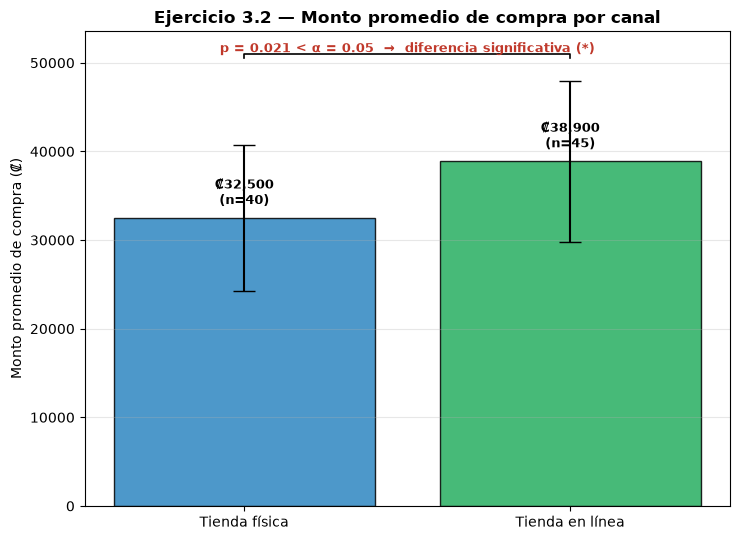

In [16]:
# Datos del ejercicio 3.2
canales_32 = ["Tienda física", "Tienda en línea"]
medias_32 = [32500, 38900]
desv_32 = [8200, 9100]
n_32 = [40, 45]
valor_p_32 = 0.021
alfa_32 = 0.05

fig, ax = plt.subplots(figsize=(7.5, 5.5))
colores_32 = [AZUL, VERDE]
bars = ax.bar(canales_32, medias_32, yerr=desv_32, capsize=8,
              color=colores_32, edgecolor="black", alpha=0.85)

for bar, media, n in zip(bars, medias_32, n_32):
    ax.annotate(f"₡{media:,.0f}\n(n={n})", (bar.get_x() + bar.get_width() / 2, media),
                textcoords="offset points", xytext=(0, 10), ha="center",
                fontsize=9, fontweight="bold")

# Línea y asterisco indicando diferencia significativa
y_linea = max(medias_32) + max(desv_32) + 2500
ax.plot([0, 0, 1, 1], [y_linea, y_linea + 500, y_linea + 500, y_linea], color="black", linewidth=1.2)
ax.text(0.5, y_linea + 700, f"p = {valor_p_32} < α = {alfa_32}  →  diferencia significativa (*)",
        ha="center", fontsize=9, fontweight="bold", color=ROJO_OSCURO)

ax.set_title("Ejercicio 3.2 — Monto promedio de compra por canal", fontsize=12, fontweight="bold")
ax.set_ylabel("Monto promedio de compra (₡)")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

**Qué se visualiza:** barras con error (media ± desviación estándar) por canal de venta, más una línea de significancia entre ambas barras.

**Razonamiento:** la tienda en línea vende en promedio ₡6,400 más por compra que la tienda física, y esa diferencia es estadísticamente significativa (p = 0.021 < 0.05).

**Conclusión:** como la diferencia no es atribuible al azar, vale la pena investigar qué factores del canal en línea (variedad, promociones, compra impulsiva) explican el ticket promedio más alto, y usar ese canal como referencia para mejorar el físico.


### Ejercicio 3.3 — ANOVA de cuatro turnos (resultado global)

El ANOVA no compara medias específicas (no se dieron datos por turno), solo
arroja un valor p global. Se visualiza la decisión de rechazo frente a α.

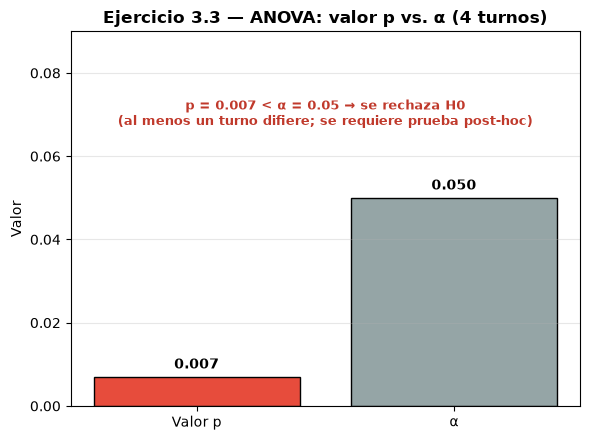

In [17]:
# Datos del ejercicio 3.3
valor_p_33 = 0.007
alfa_33 = 0.05

fig, ax = plt.subplots(figsize=(6, 4.5))
barras = ax.bar(["Valor p", "α"], [valor_p_33, alfa_33],
                 color=[ROJO, "#95A5A6"], edgecolor="black")
for bar, val in zip(barras, [valor_p_33, alfa_33]):
    ax.annotate(f"{val:.3f}", (bar.get_x() + bar.get_width() / 2, val),
                textcoords="offset points", xytext=(0, 6), ha="center", fontweight="bold")

ax.set_title("Ejercicio 3.3 — ANOVA: valor p vs. α (4 turnos)", fontsize=12, fontweight="bold")
ax.set_ylabel("Valor")
ax.grid(alpha=0.3, axis="y")
ax.text(0.5, max(valor_p_33, alfa_33) * 1.35,
        "p = 0.007 < α = 0.05 → se rechaza H0\n(al menos un turno difiere; se requiere prueba post-hoc)",
        ha="center", fontsize=9, color=ROJO_OSCURO, fontweight="bold")
ax.set_ylim(0, max(valor_p_33, alfa_33) * 1.8)
plt.tight_layout()
plt.show()

**Qué se visualiza:** comparación simple entre el valor p global del ANOVA y α, ya que el ejercicio no entrega las medias individuales por turno.

**Dato lógico integrador (no hay datos por turno):** el ANOVA solo confirma que existe al menos una diferencia entre los 4 turnos, pero no indica cuáles turnos difieren entre sí; sin esos datos no es posible graficar una comparación de medias como en los ejercicios 3.2 o 4.3, así que el gráfico se limita a mostrar la decisión global frente a α.

**Conclusión:** el resultado (p = 0.007 < 0.05) exige un análisis complementario —una prueba post-hoc, por ejemplo Tukey HSD— para identificar qué turno(s) se aparta(n) del resto antes de tomar decisiones operativas por turno.


### Ejercicio 4.3 — Caso integrador: tiempo de resolución de quejas

Comparación del tiempo promedio de resolución de quejas entre el equipo de
soporte A y el equipo B (valor p = 0.006, α = 0.05 → se rechaza H0).

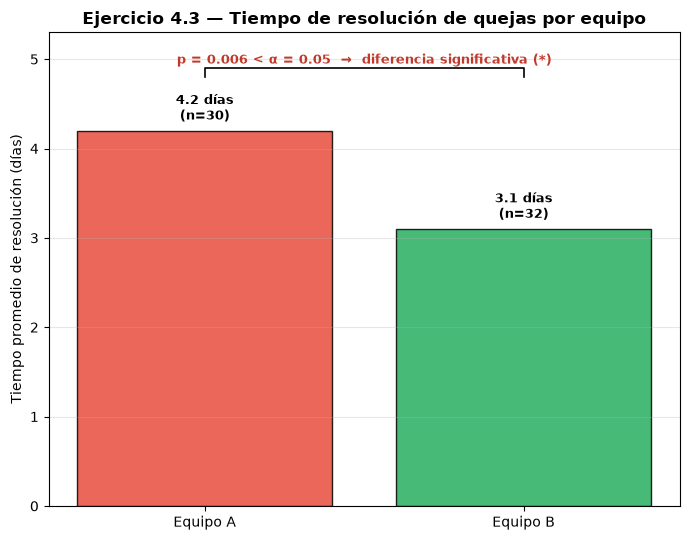

In [18]:
# Datos del ejercicio 4.3
equipos_43 = ["Equipo A", "Equipo B"]
medias_43 = [4.2, 3.1]
n_43 = [30, 32]
valor_p_43 = 0.006
alfa_43 = 0.05

fig, ax = plt.subplots(figsize=(7, 5.5))
colores_43 = [ROJO, VERDE]
bars = ax.bar(equipos_43, medias_43, color=colores_43, edgecolor="black", alpha=0.85)

for bar, media, n in zip(bars, medias_43, n_43):
    ax.annotate(f"{media} días\n(n={n})", (bar.get_x() + bar.get_width() / 2, media),
                textcoords="offset points", xytext=(0, 8), ha="center",
                fontsize=9, fontweight="bold")

y_linea = max(medias_43) + 0.6
ax.plot([0, 0, 1, 1], [y_linea, y_linea + 0.1, y_linea + 0.1, y_linea], color="black", linewidth=1.2)
ax.text(0.5, y_linea + 0.15, f"p = {valor_p_43} < α = {alfa_43}  →  diferencia significativa (*)",
        ha="center", fontsize=9, fontweight="bold", color=ROJO_OSCURO)

ax.set_title("Ejercicio 4.3 — Tiempo de resolución de quejas por equipo", fontsize=12, fontweight="bold")
ax.set_ylabel("Tiempo promedio de resolución (días)")
ax.set_ylim(0, y_linea + 0.5)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

**Qué se visualiza:** barras comparando el tiempo promedio de resolución de quejas por equipo, con línea de significancia.

**Razonamiento:** el Equipo B resuelve quejas en promedio 1.1 días más rápido que el Equipo A, y la diferencia es significativa (p = 0.006 < 0.05).

**Conclusión:** conviene estudiar las prácticas del Equipo B (protocolos, dotación de personal, escalamiento) para replicarlas en el Equipo A y bajar el tiempo de resolución general.


## Tema 4 — Interpretación de resultados

### Ejercicio 4.1 — Significancia estadística vs. relevancia práctica

Diferencia de 0.4 segundos en el tiempo de pago, estadísticamente significativa
(p = 0.001) gracias al gran tamaño de muestra (n = 8 000). Se ilustra cómo el
valor p disminuye a medida que crece n, aunque el efecto observado (0.4 s) se
mantenga igual — mostrando que "significativo" no equivale a "relevante".

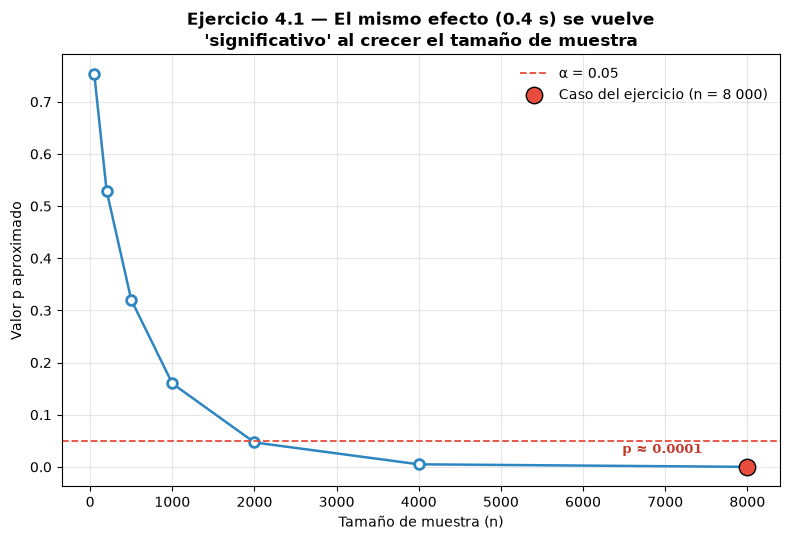

Nota: curva ilustrativa basada en el mismo efecto de 0.4 s observado en el ejercicio;
el objetivo es mostrar el concepto (a mayor n, menor valor p para el mismo efecto),
no reproducir el cálculo exacto del caso, que no incluye la desviación estándar real.


In [20]:
# Ilustración: cómo el tamaño de muestra infla la significancia de un efecto pequeño
from scipy import stats

diferencia = 0.4          # segundos, efecto observado (constante)
desv_estimada = 9.0        # desviación estándar aproximada de referencia
tamanos_n = np.array([50, 200, 500, 1000, 2000, 4000, 8000])

# Error estándar y valor p aproximado (prueba z de dos colas) para cada n,
# manteniendo el mismo efecto observado de 0.4 segundos
errores_estandar = desv_estimada / np.sqrt(tamanos_n)
z = diferencia / errores_estandar
valores_p_simulados = 2 * (1 - stats.norm.cdf(z))

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(tamanos_n, valores_p_simulados, marker="o", color=AZUL,
        markersize=7, markerfacecolor="white", markeredgewidth=2, linewidth=1.8)
ax.axhline(0.05, color=ROJO, linestyle="--", linewidth=1.3, label="α = 0.05")
ax.scatter([8000], [valores_p_simulados[-1]], color=ROJO, s=140, zorder=4,
           edgecolor="black", label="Caso del ejercicio (n = 8 000)")
ax.annotate(f"p ≈ {valores_p_simulados[-1]:.4f}", (8000, valores_p_simulados[-1]),
            textcoords="offset points", xytext=(-90, 10), fontsize=9,
            color=ROJO_OSCURO, fontweight="bold")

ax.set_title("Ejercicio 4.1 — El mismo efecto (0.4 s) se vuelve\n'significativo' al crecer el tamaño de muestra",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Tamaño de muestra (n)")
ax.set_ylabel("Valor p aproximado")
ax.grid(alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print("Nota: curva ilustrativa basada en el mismo efecto de 0.4 s observado en el ejercicio;")
print("el objetivo es mostrar el concepto (a mayor n, menor valor p para el mismo efecto),")
print("no reproducir el cálculo exacto del caso, que no incluye la desviación estándar real.")

**Qué se visualiza:** curva del valor p aproximado en función del tamaño de muestra (n), para un efecto fijo de 0.4 segundos, mostrando cómo ese mismo efecto cruza el umbral α = 0.05 a medida que n crece.

**Dato lógico integrador (no hay una desviación estándar real del caso):** el ejercicio no entrega la desviación estándar real del proceso de pago, así que la curva usa una referencia aproximada (9.0 s) solo para ilustrar el principio general — no reproduce el cálculo exacto del caso (que da p = 0.001 con n = 8,000), pero sí el fenómeno: a mayor n, el mismo efecto observado produce un valor p menor.

**Conclusión:** "estadísticamente significativo" no es lo mismo que "relevante en la práctica"; con muestras muy grandes, hasta diferencias mínimas y sin impacto real en el negocio (0.4 segundos en un pago) pueden aparecer como significativas.


## Conclusión

Las gráficas anteriores acompañan visualmente las respuestas ya desarrolladas
en el documento del quiz: los valores atípicos identificados por RIC (1.1 y
1.2), la comparación de variabilidad relativa entre productos (1.3), las
decisiones de rechazo de H0 frente a α (2.2 y 3.3), las diferencias
significativas entre grupos (3.2 y 4.3), y el efecto del tamaño de muestra
sobre la significancia estadística (4.1).

## Menú interactivo — seleccionar una tabla o gráfica por número

Ejecutá esta celda DESPUÉS de correr todas las celdas anteriores del notebook. El menú no vuelve a calcular nada desde cero: reutiliza las variables ya creadas arriba (`df_pedidos`, `resumen_112`, `df_113`, `casos_22`, `canales_32`, `equipos_43`, `valores_p_simulados`, etc.) para volver a mostrar, bajo demanda, cualquier tabla o gráfica ya generada, junto con su análisis (qué se visualiza, razonamiento y conclusión), sin tener que desplazarse por todo el notebook cada vez.


In [24]:
# ==========================================================================
# MENÚ INTERACTIVO — seleccionar una tabla o gráfica por número
# ==========================================================================
# Esta celda es AUTOCONTENIDA: no depende de que hayas ejecutado antes las
# demás celdas del notebook. Cada opción vuelve a definir sus propios datos
# (los mismos valores usados en el cuerpo del notebook) y genera la tabla o
# gráfica desde cero, junto con su análisis (qué se visualiza, razonamiento
# y conclusión). Podés correr esta celda sola, en cualquier momento.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Paleta de colores usada en los notebooks del caso LMB
AZUL = "#2E86C1"
AZUL_CLARO = "#AED6F1"
AZUL_OSCURO = "#1B4F72"
ROJO = "#E74C3C"
ROJO_OSCURO = "#C0392B"
VERDE = "#27AE60"


def _explicar(titulo, texto):
    """Imprime un encabezado y una explicación detallada antes de mostrar
    la tabla o gráfica correspondiente a la opción elegida."""
    print("\n" + "-" * 65)
    print(f"📌 {titulo}")
    print("-" * 65)
    print(texto)
    print()


def _grafico_111():
    pedidos = list(range(1, 16))
    montos = [18, 22, 25, 27, 29, 30, 31, 33, 35, 36, 38, 40, 42, 45, 98]
    df_pedidos = pd.DataFrame({"Pedido": pedidos, "Monto": montos})
    Q1, Q3 = 27, 40
    RIC = Q3 - Q1
    limite_inferior = Q1 - 1.5 * RIC
    limite_superior = Q3 + 1.5 * RIC
    outliers_111 = df_pedidos[(df_pedidos["Monto"] < limite_inferior) | (df_pedidos["Monto"] > limite_superior)]

    print(f"Q1 = {Q1} | Q3 = {Q3} | RIC = {RIC}")
    print(f"Límite inferior = {limite_inferior} | Límite superior = {limite_superior}")
    display(df_pedidos)

    fig, ax = plt.subplots(figsize=(7, 5.5))
    ax.boxplot(
        df_pedidos["Monto"], vert=True, patch_artist=True,
        boxprops=dict(facecolor=AZUL_CLARO, color=AZUL, linewidth=1.5),
        medianprops=dict(color=AZUL_OSCURO, linewidth=2),
        whiskerprops=dict(color=AZUL, linewidth=1.5),
        capprops=dict(color=AZUL, linewidth=1.5),
        flierprops=dict(marker="o", markerfacecolor=ROJO, markeredgecolor=ROJO_OSCURO, markersize=9)
    )
    for _, row in outliers_111.iterrows():
        ax.annotate(f"Pedido {row['Pedido']}: {row['Monto']}",
                    (1, row["Monto"]), textcoords="offset points",
                    xytext=(15, 0), fontsize=9, color=ROJO_OSCURO, fontweight="bold")
    ax.set_title("Ejercicio 1.1 — Boxplot del monto de pedidos (RIC)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Monto (miles de ₡)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def _grafico_112():
    resumen_112 = {"Mínimo": 1, "Q1": 2, "Mediana": 3, "Q3": 4, "Máximo": 6}
    valor_atipico_112 = 14
    RIC_112 = resumen_112["Q3"] - resumen_112["Q1"]
    limite_superior_112 = resumen_112["Q3"] + 1.5 * RIC_112

    print(f"Resumen de 5 números: {resumen_112}")
    print(f"Valor atípico: {valor_atipico_112} días | RIC = {RIC_112} | Límite superior = {limite_superior_112:.1f}")

    fig, ax = plt.subplots(figsize=(7, 5.5))
    ax.plot([1, 1], [resumen_112["Mínimo"], resumen_112["Q1"]], color=AZUL, linewidth=1.5)
    ax.plot([1, 1], [resumen_112["Q3"], resumen_112["Máximo"]], color=AZUL, linewidth=1.5)
    ax.add_patch(plt.Rectangle((0.75, resumen_112["Q1"]), 0.5,
                                resumen_112["Q3"] - resumen_112["Q1"],
                                facecolor=AZUL_CLARO, edgecolor=AZUL, linewidth=1.5))
    ax.plot([0.75, 1.25], [resumen_112["Mediana"]] * 2, color=AZUL_OSCURO, linewidth=2)
    ax.plot([0.9, 1.1], [resumen_112["Mínimo"]] * 2, color=AZUL, linewidth=1.5)
    ax.plot([0.9, 1.1], [resumen_112["Máximo"]] * 2, color=AZUL, linewidth=1.5)
    ax.scatter([1], [valor_atipico_112], color=ROJO, s=140, zorder=4,
               edgecolor="black", label="Valor atípico")
    ax.annotate(f"{valor_atipico_112} días (atípico)", (1, valor_atipico_112),
                textcoords="offset points", xytext=(15, 0), fontsize=9,
                color=ROJO_OSCURO, fontweight="bold")
    ax.axhline(limite_superior_112, color=ROJO, linestyle="--", linewidth=1.3,
               label=f"Límite superior = {limite_superior_112:.1f} días")
    ax.set_title("Ejercicio 1.2 — Boxplot del tiempo de entrega (50 pedidos)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Tiempo de entrega (días)")
    ax.set_xticks([1])
    ax.set_xticklabels(["Pedidos LMB"])
    ax.set_xlim(0.5, 1.7)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left", fontsize=9, frameon=False)
    plt.tight_layout()
    plt.show()


def _grafico_113():
    productos_113 = ["Producto A", "Producto B"]
    medias_113 = [45000, 18000]
    desv_113 = [6750, 5400]
    cv_113 = [d / m * 100 for m, d in zip(medias_113, desv_113)]
    df_113 = pd.DataFrame({"Producto": productos_113, "Media": medias_113,
                            "Desviación": desv_113, "CV (%)": cv_113})
    colores_113 = [AZUL, ROJO]

    display(df_113)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].bar(productos_113, medias_113, yerr=desv_113, color=colores_113,
                capsize=8, edgecolor="black", alpha=0.85)
    axes[0].set_title("Media ± desviación estándar (absoluta)", fontsize=11, fontweight="bold")
    axes[0].set_ylabel("Monto de venta diario (₡)")
    axes[0].grid(alpha=0.3, axis="y")
    bars = axes[1].bar(productos_113, cv_113, color=colores_113, edgecolor="black", alpha=0.85)
    for bar, cv in zip(bars, cv_113):
        axes[1].annotate(f"{cv:.0f}%", (bar.get_x() + bar.get_width() / 2, cv),
                          textcoords="offset points", xytext=(0, 6),
                          ha="center", fontsize=10, fontweight="bold")
    axes[1].set_title("Coeficiente de variación (relativa)", fontsize=11, fontweight="bold")
    axes[1].set_ylabel("CV (%)")
    axes[1].grid(alpha=0.3, axis="y")
    plt.suptitle("Ejercicio 1.3 — Variabilidad absoluta vs. relativa", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


def _grafico_22():
    casos_22 = ["Caso A", "Caso B", "Caso C"]
    valores_p_22 = [0.032, 0.184, 0.049]
    alfas_22 = [0.05, 0.05, 0.01]
    decision_22 = ["Rechaza H0" if p < a else "No rechaza H0" for p, a in zip(valores_p_22, alfas_22)]
    colores_22 = [ROJO if p < a else AZUL for p, a in zip(valores_p_22, alfas_22)]

    for caso, p, a, d in zip(casos_22, valores_p_22, alfas_22, decision_22):
        print(f"{caso}: p = {p}, α = {a} -> {d}")

    fig, ax = plt.subplots(figsize=(8, 5.5))
    x = np.arange(len(casos_22))
    ancho = 0.35
    ax.bar(x - ancho / 2, valores_p_22, ancho, label="Valor p", color=colores_22, edgecolor="black")
    ax.bar(x + ancho / 2, alfas_22, ancho, label="α", color="#95A5A6", edgecolor="black", alpha=0.7)
    for i, (p, a, d) in enumerate(zip(valores_p_22, alfas_22, decision_22)):
        ax.annotate(d, (x[i], max(p, a) + 0.01), ha="center", fontsize=9,
                    fontweight="bold", color=ROJO_OSCURO if "Rechaza" in d else AZUL_OSCURO)
    ax.set_xticks(x)
    ax.set_xticklabels(casos_22)
    ax.set_ylabel("Valor")
    ax.set_title("Ejercicio 2.2 — Valor p vs. α por caso", fontsize=12, fontweight="bold")
    ax.grid(alpha=0.3, axis="y")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


def _grafico_32():
    canales_32 = ["Tienda física", "Tienda en línea"]
    medias_32 = [32500, 38900]
    desv_32 = [8200, 9100]
    n_32 = [40, 45]
    valor_p_32 = 0.021
    alfa_32 = 0.05
    colores_32 = [AZUL, VERDE]

    print(f"Valor p = {valor_p_32} | α = {alfa_32}")
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    bars = ax.bar(canales_32, medias_32, yerr=desv_32, capsize=8,
                  color=colores_32, edgecolor="black", alpha=0.85)
    for bar, media, n in zip(bars, medias_32, n_32):
        ax.annotate(f"₡{media:,.0f}\n(n={n})", (bar.get_x() + bar.get_width() / 2, media),
                    textcoords="offset points", xytext=(0, 10), ha="center",
                    fontsize=9, fontweight="bold")
    y_linea = max(medias_32) + max(desv_32) + 2500
    ax.plot([0, 0, 1, 1], [y_linea, y_linea + 500, y_linea + 500, y_linea], color="black", linewidth=1.2)
    ax.text(0.5, y_linea + 700, f"p = {valor_p_32} < α = {alfa_32}  →  diferencia significativa (*)",
            ha="center", fontsize=9, fontweight="bold", color=ROJO_OSCURO)
    ax.set_title("Ejercicio 3.2 — Monto promedio de compra por canal", fontsize=12, fontweight="bold")
    ax.set_ylabel("Monto promedio de compra (₡)")
    ax.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()


def _grafico_33():
    valor_p_33 = 0.007
    alfa_33 = 0.05

    print(f"Valor p = {valor_p_33} | α = {alfa_33}")
    fig, ax = plt.subplots(figsize=(6, 4.5))
    barras = ax.bar(["Valor p", "α"], [valor_p_33, alfa_33],
                     color=[ROJO, "#95A5A6"], edgecolor="black")
    for bar, val in zip(barras, [valor_p_33, alfa_33]):
        ax.annotate(f"{val:.3f}", (bar.get_x() + bar.get_width() / 2, val),
                    textcoords="offset points", xytext=(0, 6), ha="center", fontweight="bold")
    ax.set_title("Ejercicio 3.3 — ANOVA: valor p vs. α (4 turnos)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Valor")
    ax.grid(alpha=0.3, axis="y")
    ax.text(0.5, max(valor_p_33, alfa_33) * 1.35,
            "p = 0.007 < α = 0.05 → se rechaza H0\n(al menos un turno difiere; se requiere prueba post-hoc)",
            ha="center", fontsize=9, color=ROJO_OSCURO, fontweight="bold")
    ax.set_ylim(0, max(valor_p_33, alfa_33) * 1.8)
    plt.tight_layout()
    plt.show()


def _grafico_43():
    equipos_43 = ["Equipo A", "Equipo B"]
    medias_43 = [4.2, 3.1]
    n_43 = [30, 32]
    valor_p_43 = 0.006
    alfa_43 = 0.05
    colores_43 = [ROJO, VERDE]

    print(f"Valor p = {valor_p_43} | α = {alfa_43}")
    fig, ax = plt.subplots(figsize=(7, 5.5))
    bars = ax.bar(equipos_43, medias_43, color=colores_43, edgecolor="black", alpha=0.85)
    for bar, media, n in zip(bars, medias_43, n_43):
        ax.annotate(f"{media} días\n(n={n})", (bar.get_x() + bar.get_width() / 2, media),
                    textcoords="offset points", xytext=(0, 8), ha="center",
                    fontsize=9, fontweight="bold")
    y_linea = max(medias_43) + 0.6
    ax.plot([0, 0, 1, 1], [y_linea, y_linea + 0.1, y_linea + 0.1, y_linea], color="black", linewidth=1.2)
    ax.text(0.5, y_linea + 0.15, f"p = {valor_p_43} < α = {alfa_43}  →  diferencia significativa (*)",
            ha="center", fontsize=9, fontweight="bold", color=ROJO_OSCURO)
    ax.set_title("Ejercicio 4.3 — Tiempo de resolución de quejas por equipo", fontsize=12, fontweight="bold")
    ax.set_ylabel("Tiempo promedio de resolución (días)")
    ax.set_ylim(0, y_linea + 0.5)
    ax.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()


def _grafico_41():
    from scipy import stats

    diferencia = 0.4          # segundos, efecto observado (constante)
    desv_estimada = 9.0       # desviación estándar aproximada de referencia
    tamanos_n = np.array([50, 200, 500, 1000, 2000, 4000, 8000])
    errores_estandar = desv_estimada / np.sqrt(tamanos_n)
    z = diferencia / errores_estandar
    valores_p_simulados = 2 * (1 - stats.norm.cdf(z))

    print(f"p aproximado en n = 8,000: {valores_p_simulados[-1]:.4f}")
    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.plot(tamanos_n, valores_p_simulados, marker="o", color=AZUL,
            markersize=7, markerfacecolor="white", markeredgewidth=2, linewidth=1.8)
    ax.axhline(0.05, color=ROJO, linestyle="--", linewidth=1.3, label="α = 0.05")
    ax.scatter([8000], [valores_p_simulados[-1]], color=ROJO, s=140, zorder=4,
               edgecolor="black", label="Caso del ejercicio (n = 8 000)")
    ax.annotate(f"p ≈ {valores_p_simulados[-1]:.4f}", (8000, valores_p_simulados[-1]),
                textcoords="offset points", xytext=(-90, 10), fontsize=9,
                color=ROJO_OSCURO, fontweight="bold")
    ax.set_title("Ejercicio 4.1 — El mismo efecto (0.4 s) se vuelve\n'significativo' al crecer el tamaño de muestra",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Tamaño de muestra (n)")
    ax.set_ylabel("Valor p aproximado")
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


def menu_quiz():
    intentos_invalidos = 0
    MAX_INTENTOS = 5  # corta el bucle si algo anda mal (ej. input vacío repetido)

    while True:
        print("\n" + "=" * 65)
        print(" MENÚ — Quiz Módulo 3 (EDA): Tablas y Gráficas")
        print("=" * 65)
        print(""" 1. Ejercicio 1.1 — Boxplot del monto de pedidos (RIC)
 2. Ejercicio 1.2 — Boxplot del tiempo de entrega (resumen de 5 números)
 3. Ejercicio 1.3 — Variabilidad absoluta vs. relativa (CV)
 4. Ejercicio 2.2 — Valor p vs. α por caso
 5. Ejercicio 3.2 — Monto promedio de compra por canal
 6. Ejercicio 3.3 — ANOVA: valor p vs. α (4 turnos)
 7. Ejercicio 4.3 — Tiempo de resolución de quejas por equipo
 8. Ejercicio 4.1 — Significancia vs. tamaño de muestra
 9. Interpretación final de resultados (conclusión general)
 0. Salir del menú""")

        try:
            eleccion = input("\nElegí un número de opción: ").strip()
        except EOFError:
            print("\n⚠️  No se recibió entrada (¿se ejecutó sin modo interactivo?). Saliendo del menú.")
            break

        if eleccion == "":
            intentos_invalidos += 1
            print("⚠️  No escribiste nada. Ingresá un número entre 0 y 9.")
            if intentos_invalidos >= MAX_INTENTOS:
                print("⚠️  Demasiados intentos vacíos seguidos. Saliendo del menú.")
                break
            continue

        intentos_invalidos = 0  # se resetea al recibir algo no vacío

        if eleccion == "1":
            _explicar(
                "Ejercicio 1.1 — Boxplot del monto de pedidos (RIC)",
                "Boxplot vertical de los montos de los 15 pedidos. La caja representa Q1-Q3\n"
                "(27 a 40 mil colones), la línea interna es la mediana, y el punto rojo es el\n"
                "Pedido 15 (98 mil), marcado como atípico porque supera el límite superior de\n"
                "Tukey (59.5). Conclusión: hay un pedido claramente fuera de patrón que conviene\n"
                "revisar antes de usar el monto promedio en proyecciones."
            )
            _grafico_111()

        elif eleccion == "2":
            _explicar(
                "Ejercicio 1.2 — Boxplot del tiempo de entrega (resumen de 5 números)",
                "Boxplot reconstruido a mano porque no hay datos crudos, solo el resumen de 5\n"
                "números (Mín=1, Q1=2, Mediana=3, Q3=4, Máx=6). El valor atípico (14 días) se\n"
                "grafica aparte porque excede el límite superior de Tukey (7). Dato lógico\n"
                "integrador: al no tener las 50 observaciones originales, este resumen alcanza\n"
                "para detectar el atípico, pero no muestra la forma completa de la distribución."
            )
            _grafico_112()

        elif eleccion == "3":
            _explicar(
                "Ejercicio 1.3 — Variabilidad absoluta vs. relativa (CV)",
                "Dos gráficos de barras: media ± desviación estándar (variabilidad absoluta) y\n"
                "coeficiente de variación (variabilidad relativa) para el Producto A y el\n"
                "Producto B. El Producto A tiene mayor desviación absoluta, pero menor CV (15%\n"
                "vs. 30%) porque su media también es más alta. Conclusión: para comparar\n"
                "productos con escalas de venta distintas, el CV es la métrica correcta."
            )
            _grafico_113()

        elif eleccion == "4":
            _explicar(
                "Ejercicio 2.2 — Valor p vs. α por caso",
                "Barras agrupadas comparando valor p contra α en tres casos, con la decisión\n"
                "(Rechaza / No rechaza H0) anotada sobre cada par. Solo el Caso A rechaza H0.\n"
                "El Caso C tiene un p bajo (0.049) pero su α es más estricto (0.01), así que no\n"
                "alcanza significancia. Conclusión: un valor p pequeño no garantiza significancia\n"
                "si el criterio (α) es más exigente."
            )
            _grafico_22()

        elif eleccion == "5":
            _explicar(
                "Ejercicio 3.2 — Monto promedio de compra por canal",
                "Barras con error (media ± desviación estándar) por canal, más una línea de\n"
                "significancia. La tienda en línea vende en promedio ₡6,400 más por compra que\n"
                "la tienda física, diferencia significativa (p = 0.021 < 0.05). Conclusión: vale\n"
                "la pena investigar qué factores del canal en línea explican el ticket promedio\n"
                "más alto."
            )
            _grafico_32()

        elif eleccion == "6":
            _explicar(
                "Ejercicio 3.3 — ANOVA: valor p vs. α (4 turnos)",
                "Comparación simple entre el valor p global del ANOVA y α, ya que el ejercicio\n"
                "no entrega las medias por turno. Dato lógico integrador: el ANOVA solo confirma\n"
                "que existe al menos una diferencia entre los 4 turnos, sin decir cuáles; sin\n"
                "esos datos no se puede graficar una comparación de medias como en 3.2 o 4.3.\n"
                "Conclusión: el resultado (p = 0.007 < 0.05) exige una prueba post-hoc (ej. Tukey\n"
                "HSD) para identificar qué turno(s) difiere(n) del resto."
            )
            _grafico_33()

        elif eleccion == "7":
            _explicar(
                "Ejercicio 4.3 — Tiempo de resolución de quejas por equipo",
                "Barras comparando el tiempo promedio de resolución de quejas por equipo, con\n"
                "línea de significancia. El Equipo B resuelve quejas en promedio 1.1 días más\n"
                "rápido que el A (p = 0.006 < 0.05). Conclusión: conviene estudiar las prácticas\n"
                "del Equipo B para replicarlas en el Equipo A."
            )
            _grafico_43()

        elif eleccion == "8":
            _explicar(
                "Ejercicio 4.1 — Significancia vs. tamaño de muestra",
                "Curva del valor p aproximado en función de n, para un efecto fijo de 0.4\n"
                "segundos. Dato lógico integrador: no hay una desviación estándar real del caso,\n"
                "así que la curva usa una referencia aproximada (9.0 s) solo para ilustrar el\n"
                "principio general, no para reproducir el p = 0.001 exacto del ejercicio.\n"
                "Conclusión: 'estadísticamente significativo' no es lo mismo que 'relevante en\n"
                "la práctica'."
            )
            _grafico_41()

        elif eleccion == "9":
            _explicar(
                "Interpretación final de resultados",
                "Resume lo que muestran en conjunto las ocho gráficas del quiz: valores\n"
                "atípicos identificados por RIC, comparación de variabilidad relativa,\n"
                "decisiones de rechazo de H0 frente a α, diferencias significativas entre\n"
                "grupos, y el efecto del tamaño de muestra sobre la significancia estadística."
            )
            print("Las gráficas de este quiz acompañan visualmente las respuestas ya desarrolladas")
            print("en el documento entregado:")
            print("- 1.1 y 1.2: los valores atípicos identificados por el método RIC (Pedido 15")
            print("  con ₡98 mil, y el caso de 14 días de entrega).")
            print("- 1.3: la variabilidad relativa (CV) es la métrica correcta para comparar")
            print("  productos con escalas de venta muy distintas (Producto B más inestable).")
            print("- 2.2 y 3.3: las decisiones de rechazo de H0 frente a α, incluyendo el caso")
            print("  donde un p 'bajo' no alcanza significancia por un α más estricto (Caso C).")
            print("- 3.2 y 4.3: diferencias significativas entre grupos (canal de venta y equipo")
            0
            print("  de soporte), con implicaciones prácticas para el negocio.")
            print("- 4.1: el mismo efecto (0.4 s) se vuelve 'significativo' solo por el tamaño de")
            print("  muestra, recordando que significancia estadística no es lo mismo que")
            print("  relevancia práctica.")

        elif eleccion == "0":
            print("Saliendo del menú.")
            break

        else:
            print("⚠️  Opción no válida. Elegí un número entre 0 y 9.")

menu_quiz()



 MENÚ — Quiz Módulo 3 (EDA): Tablas y Gráficas
 1. Ejercicio 1.1 — Boxplot del monto de pedidos (RIC)
 2. Ejercicio 1.2 — Boxplot del tiempo de entrega (resumen de 5 números)
 3. Ejercicio 1.3 — Variabilidad absoluta vs. relativa (CV)
 4. Ejercicio 2.2 — Valor p vs. α por caso
 5. Ejercicio 3.2 — Monto promedio de compra por canal
 6. Ejercicio 3.3 — ANOVA: valor p vs. α (4 turnos)
 7. Ejercicio 4.3 — Tiempo de resolución de quejas por equipo
 8. Ejercicio 4.1 — Significancia vs. tamaño de muestra
 9. Interpretación final de resultados (conclusión general)
 0. Salir del menú
Saliendo del menú.
